In [2]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os
import utils

In [3]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [4]:
query_min = "SELECT * FROM gold.active_1min"
query_30 = "SELECT * FROM gold.active_30min"
query_hr = "SELECT * FROM gold.active_1hr"
query_day = "SELECT * FROM gold.active_daily"

In [5]:
df_min = pd.read_sql(query_min,engine)
df_30 = pd.read_sql(query_30,engine)
df_hr = pd.read_sql(query_hr,engine)
df_day = pd.read_sql(query_day,engine)

Daily Volume Analysis

In [6]:
utils.get_basic_info(df_day,'total_volume')

count    2.290000e+02
mean     1.143470e+06
std      3.932360e+05
min      1.745000e+04
25%      8.909590e+05
50%      1.046006e+06
75%      1.320783e+06
max      2.635138e+06
Name: total_volume, dtype: float64
Median:  1046006.0
Std Dev:  393235.9633787837
IQR: 429824.0


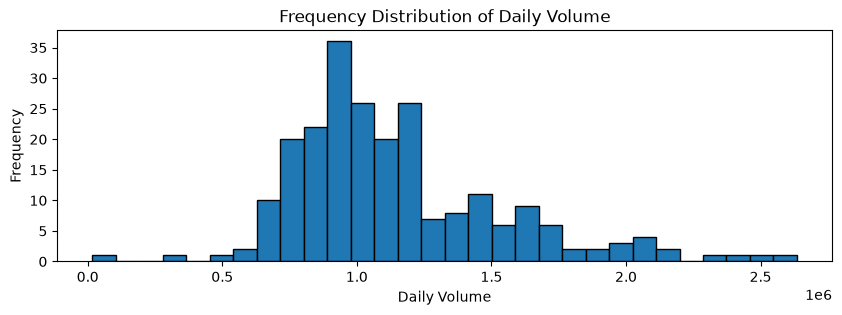

In [7]:
utils.frequency_hist(df_day,'total_volume',30,'Daily Volume')

30 Min Analysis

In [8]:
agg_30_volume, agg_IQR_30_volume = utils.aggregate_by_time(df_30,'bar_time','total_volume')

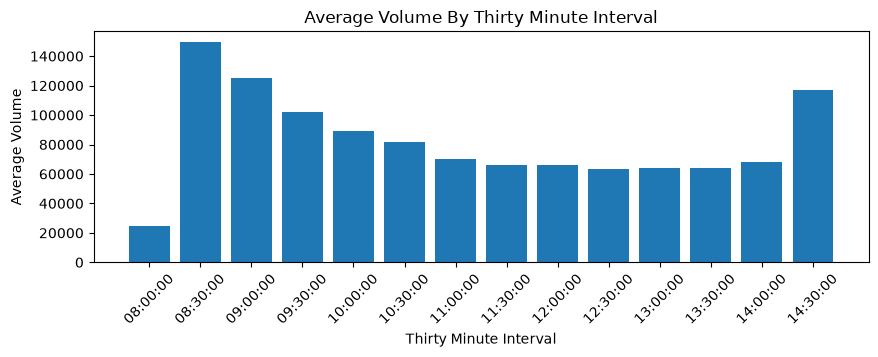

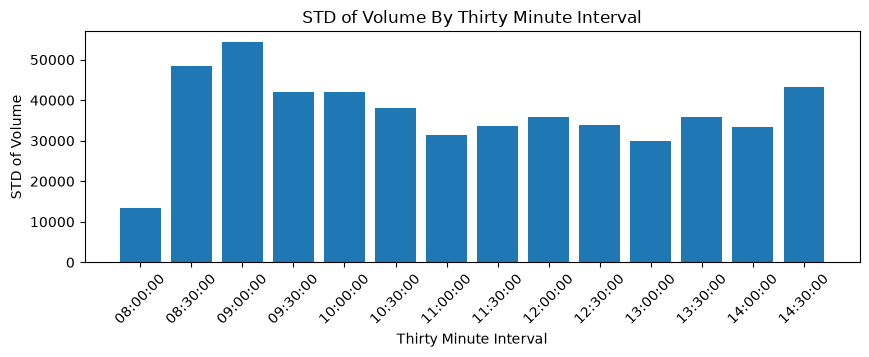

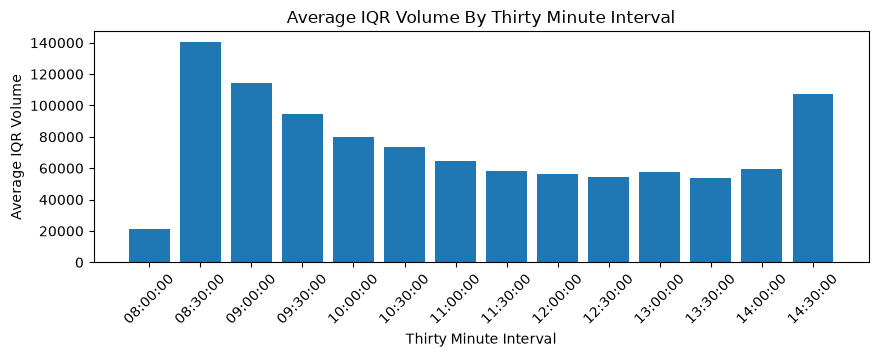

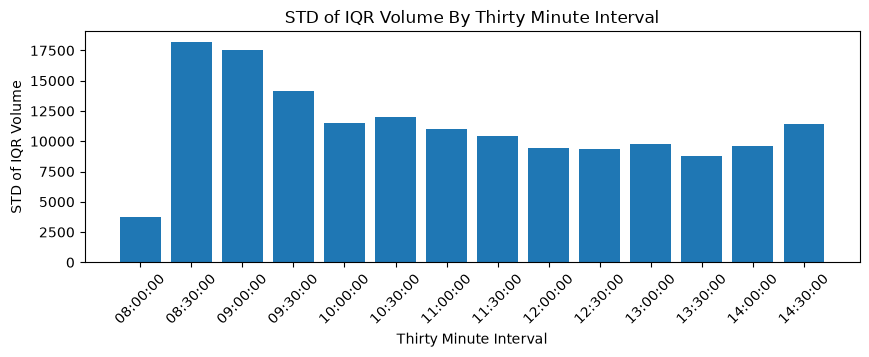

In [9]:
utils.bar_by_time(agg_30_volume,'mean','Thirty Minute Interval', 'Average Volume')
utils.bar_by_time(agg_30_volume,'std','Thirty Minute Interval', 'STD of Volume')

utils.bar_by_time(agg_IQR_30_volume,'mean','Thirty Minute Interval', 'Average IQR Volume')
utils.bar_by_time(agg_IQR_30_volume,'std','Thirty Minute Interval', 'STD of IQR Volume')

Minute Analysis

In [10]:
agg_min_volume, agg_IQR_min_volume = utils.aggregate_by_time(df_min,'bar_time','volume')

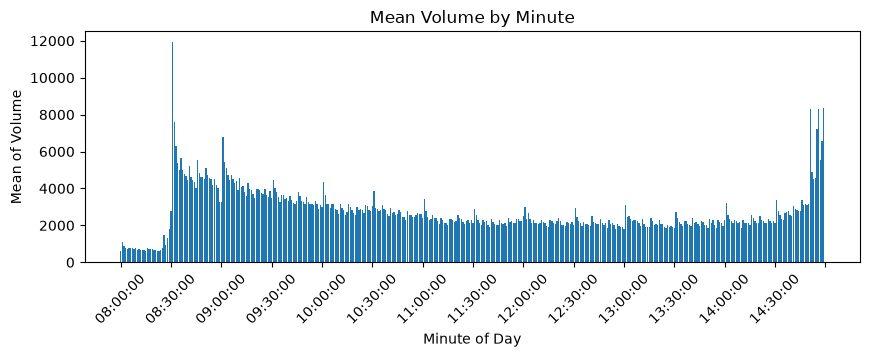

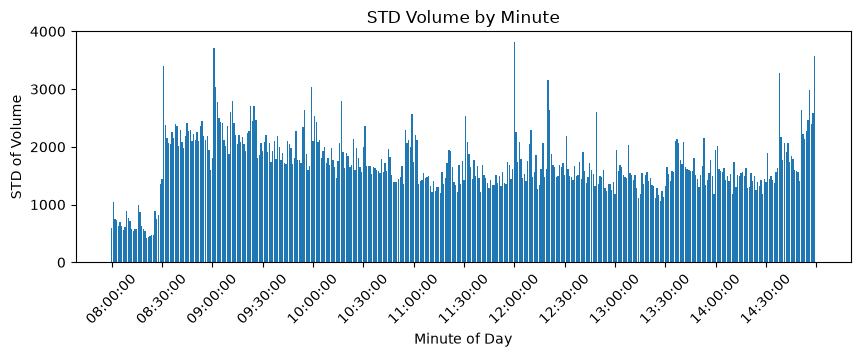

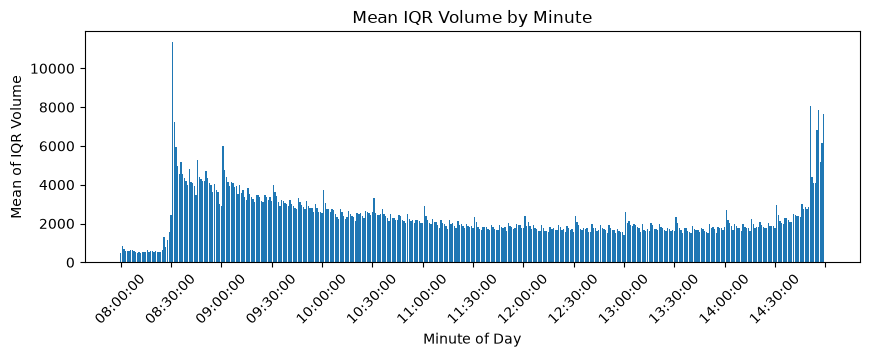

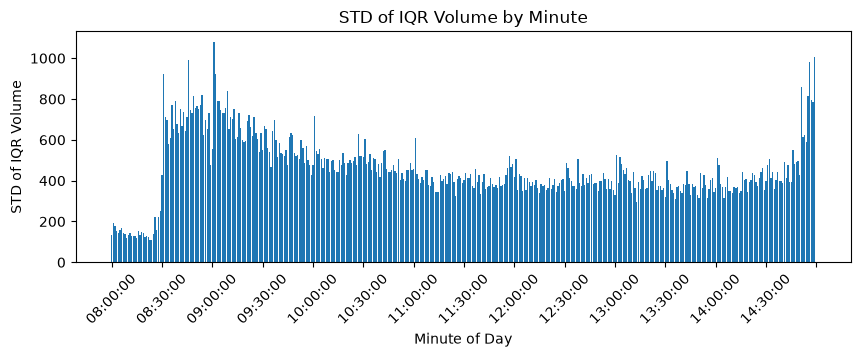

In [11]:
plt.figure(figsize=(10,3))
plt.bar(agg_min_volume.index.astype(str),agg_min_volume['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of Volume')
plt.title('Mean Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min_volume.index.astype(str),agg_min_volume['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('STD of Volume')
plt.title('STD Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_IQR_min_volume.index.astype(str),agg_IQR_min_volume['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of IQR Volume')
plt.title('Mean IQR Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_IQR_min_volume.index.astype(str),agg_IQR_min_volume['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('STD of IQR Volume')
plt.title('STD of IQR Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()